# Task 4.1: Why Scaling Matters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.read_excel('Practice_Dataset.xlsx')
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Look at the range of each numeric column
print('Column ranges BEFORE scaling:')
for col in numeric_cols:
    print(f'  {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, '
          f'mean={df[col].mean():.2f}, std={df[col].std():.2f}')

# Problem: if one column ranges 0-1000 and another 0-1,
# the large-range column will dominate distance-based models
# (KNN, SVM, K-Means, PCA, Neural Networks)

Column ranges BEFORE scaling:
  punch_count: min=0.00, max=22.00, mean=3.64, std=1.94
  hours_worked: min=7.10, max=16.50, mean=9.00, std=1.00
  monthly_salary: min=5010.00, max=45500.00, mean=8795.64, std=3346.98
  satisfaction_score: min=1.00, max=5.00, mean=3.52, std=1.10
  is_absent: min=0.00, max=1.00, mean=0.10, std=0.30


# Task 4.2: StandardScaler — Zero Mean, Unit Variance

After StandardScaler:
  punch_count: mean=0.0000, std=1.0014
  hours_worked: mean=-0.0000, std=1.0014
  monthly_salary: mean=0.0000, std=1.0014
  satisfaction_score: mean=0.0000, std=1.0014
  is_absent: mean=-0.0000, std=1.0014


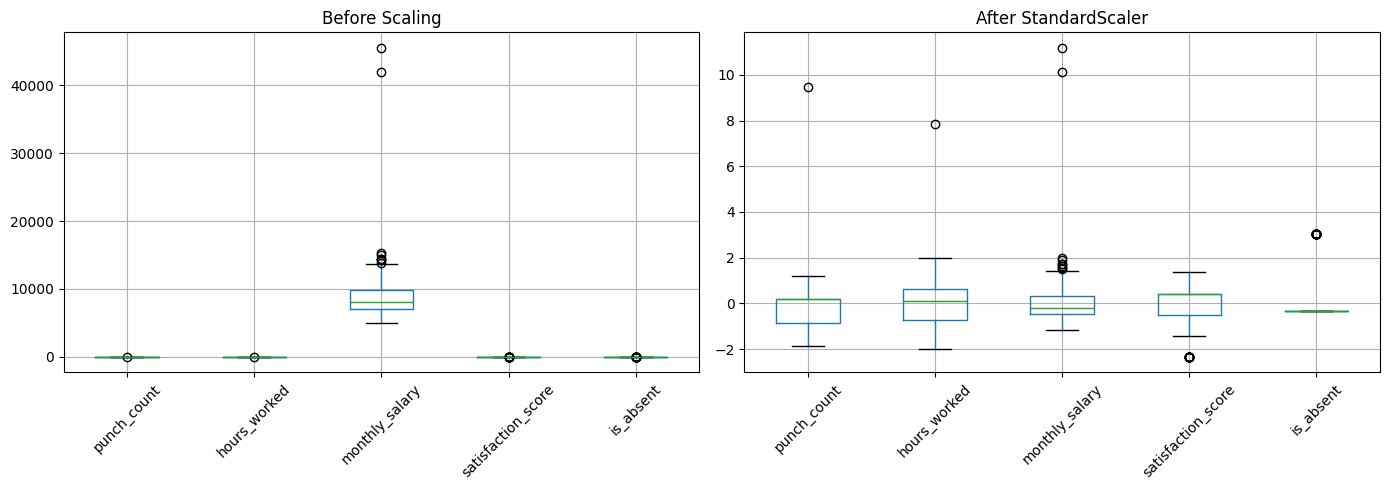

In [3]:
df = pd.read_excel('Practice_Dataset.xlsx')
numeric_cols = df.select_dtypes(include=[np.number]).columns

# z = (x - mean) / std
scaler = StandardScaler()
df_scaled = df.copy()

# Fill NaNs first — StandardScaler can't handle missing values
df_scaled[numeric_cols] = df_scaled[numeric_cols].fillna(df_scaled[numeric_cols].median())
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

print('After StandardScaler:')
for col in numeric_cols:
    print(f'  {col}: mean={df_scaled[col].mean():.4f}, std={df_scaled[col].std():.4f}')

# Visualize before vs after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
df[numeric_cols].boxplot(ax=ax1)
ax1.set_title('Before Scaling')
ax1.tick_params(axis='x', rotation=45)
df_scaled[numeric_cols].boxplot(ax=ax2)
ax2.set_title('After StandardScaler')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150)
plt.show()

# Task 4.3: MinMaxScaler — Scale to 0-1 Range

In [4]:
df = pd.read_excel('Practice_Dataset.xlsx')
numeric_cols = df.select_dtypes(include=[np.number]).columns

# x_scaled = (x - min) / (max - min)
minmax = MinMaxScaler()
df_minmax = df.copy()

# Fill NaNs first — MinMaxScaler also can't handle missing values
df_minmax[numeric_cols] = df_minmax[numeric_cols].fillna(df_minmax[numeric_cols].median())
df_minmax[numeric_cols] = minmax.fit_transform(df_minmax[numeric_cols])

print('After MinMaxScaler:')
for col in numeric_cols:
    print(f'  {col}: min={df_minmax[col].min():.4f}, max={df_minmax[col].max():.4f}')

After MinMaxScaler:
  punch_count: min=0.0000, max=1.0000
  hours_worked: min=0.0000, max=1.0000
  monthly_salary: min=0.0000, max=1.0000
  satisfaction_score: min=0.0000, max=1.0000
  is_absent: min=0.0000, max=1.0000


# Task 4.4: Log Transformation for Skewed Data

Skewness before transformation:
punch_count           1.924
hours_worked          1.202
monthly_salary        6.785
satisfaction_score   -0.458
is_absent             2.730
dtype: float64
punch_count: skew 1.924 -> -1.549
hours_worked: skew 1.202 -> 0.367
monthly_salary: skew 6.785 -> 1.667
is_absent: skew 2.730 -> 2.730


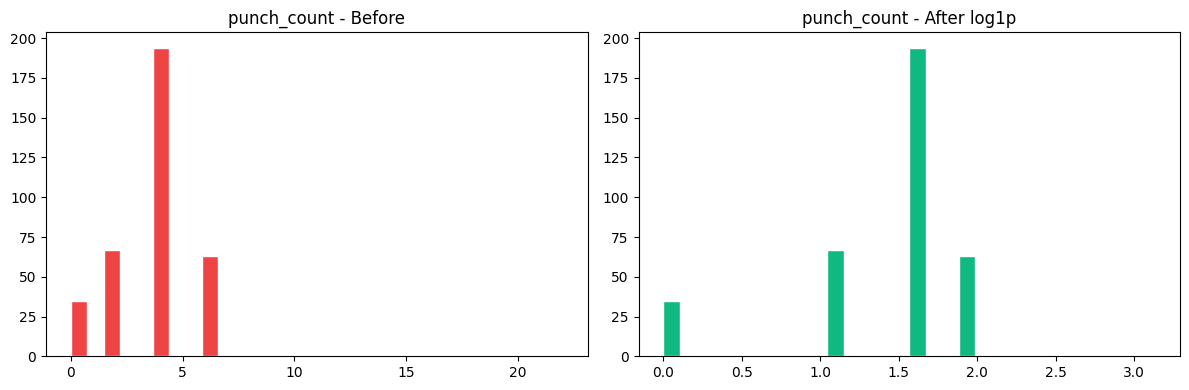

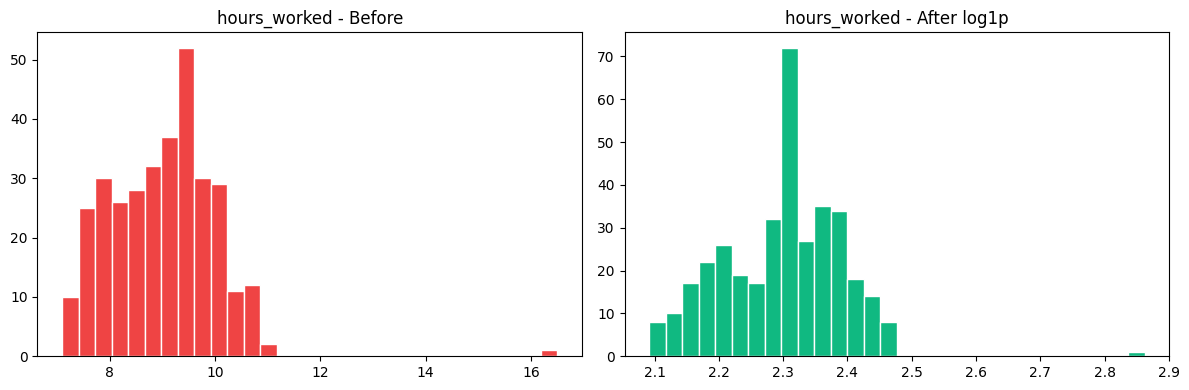

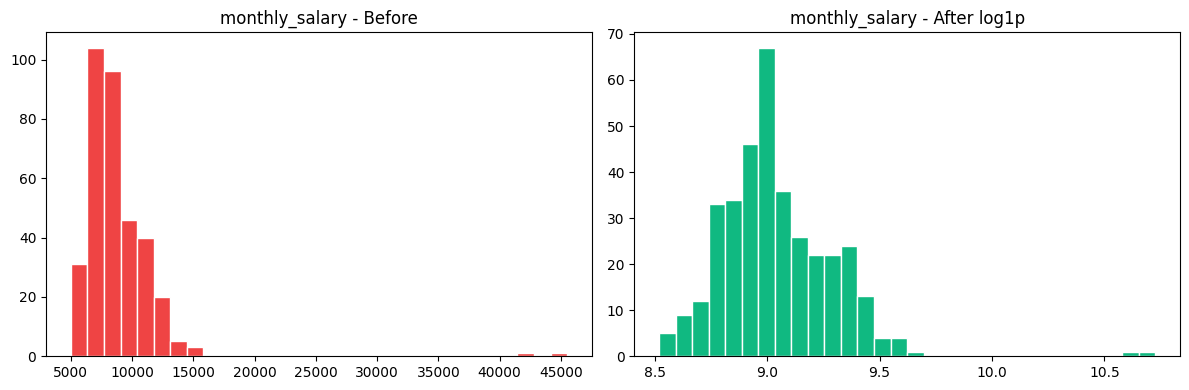

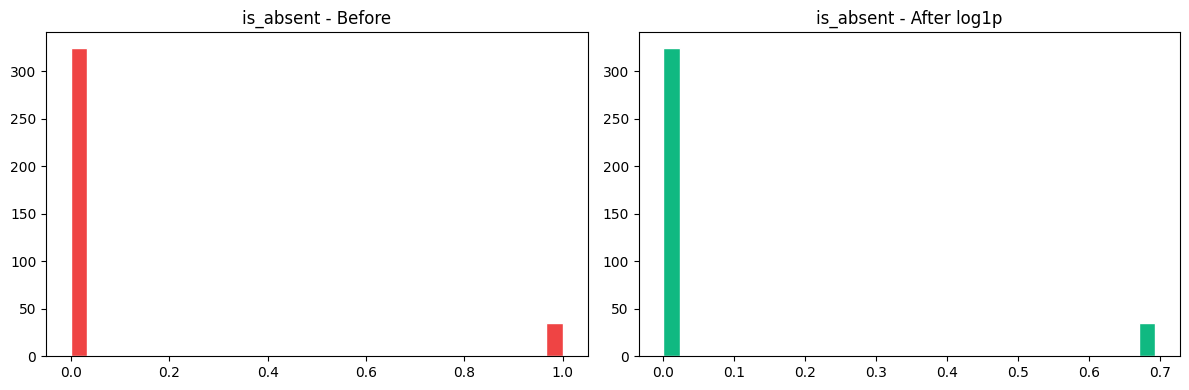

In [5]:
df = pd.read_excel('Practice_Dataset.xlsx')
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Check skewness first
print('Skewness before transformation:')
print(df[numeric_cols].skew().round(3))

df_log = df.copy()
skewed_cols = df[numeric_cols].skew()
skewed_cols = skewed_cols[skewed_cols.abs() > 1].index  # |skew| > 1

for col in skewed_cols:
    # Fill NaNs before log1p to avoid errors
    df_log[col] = df_log[col].fillna(df_log[col].median())
    df_log[col] = np.log1p(df_log[col])  # log1p handles zeros
    print(f'{col}: skew {df[col].skew():.3f} -> {df_log[col].skew():.3f}')

# Visualize before vs after
for col in skewed_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(df[col].dropna(), bins=30, color='#EF4444', edgecolor='white')
    ax1.set_title(f'{col} - Before')
    ax2.hist(df_log[col].dropna(), bins=30, color='#10B981', edgecolor='white')
    ax2.set_title(f'{col} - After log1p')
    plt.tight_layout()
    plt.savefig(f'log_transform_{col}.png', dpi=150)
    plt.show()